**cnn**

In [1]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  # Resize to 128x128
        img = img / 255.0  # Normalize pixel values
        images.append(img)
        labels.append(label)  # Assign the given label (0 or 1)
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

def build_cnn_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),  # Additional layer
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_cnn_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cnn_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cnn_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn_model.keras")
print("Model saved successfully in /kaggle/working/")

2025-05-25 11:19:09.144832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748171949.331125      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748171949.387510      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748171994.152334      35 gpu_device.cc:2022] Created device /job:localhost/repl

Epoch 1/200


I0000 00:00:1748171998.528690      98 service.cc:148] XLA service 0x7aab5c01dc40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748171998.529527      98 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748171998.529556      98 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748171998.961690      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


10/29 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5271 - loss: 4.6669

I0000 00:00:1748172002.690173      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.5524 - loss: 3.3478 - val_accuracy: 0.6939 - val_loss: 0.8000
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6802 - loss: 0.7362 - val_accuracy: 0.7347 - val_loss: 0.6380
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7474 - loss: 0.6044 - val_accuracy: 0.7449 - val_loss: 0.6454
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7361 - loss: 0.6156 - val_accuracy: 0.7755 - val_loss: 0.6026
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7651 - loss: 0.5555 - val_accuracy: 0.7551 - val_loss: 0.6750
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7952 - loss: 0.5618 - val_accuracy: 0.7755 - val_loss: 0.5831
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8484 - loss: 0.4558 - val_accuracy: 0.7755 - val_loss: 0.5730
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8833 - loss: 0.4506 - val_accuracy: 0.7449 - val

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step


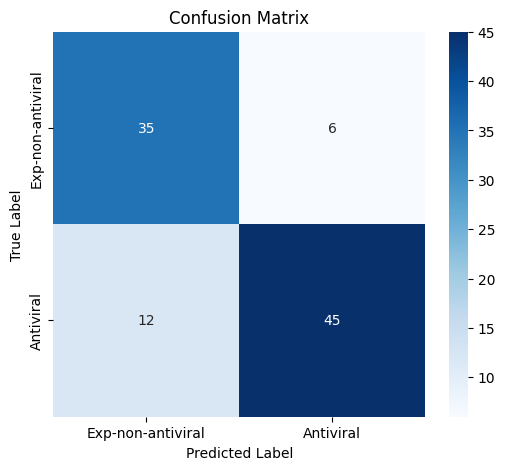


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.74      0.85      0.80        41
        Antiviral       0.88      0.79      0.83        57

         accuracy                           0.82        98
        macro avg       0.81      0.82      0.81        98
     weighted avg       0.82      0.82      0.82        98



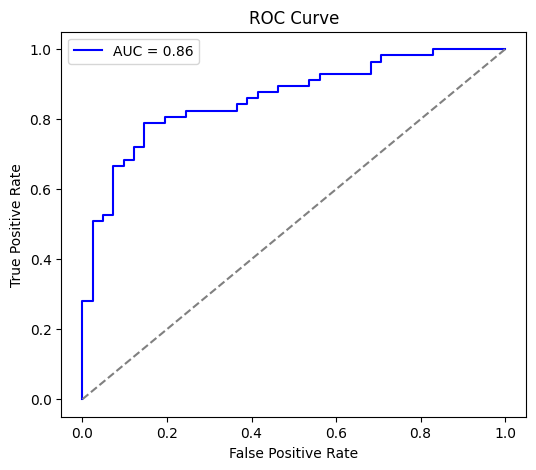

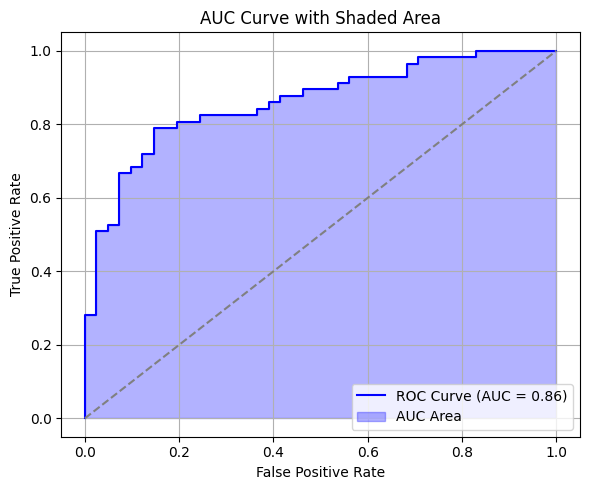

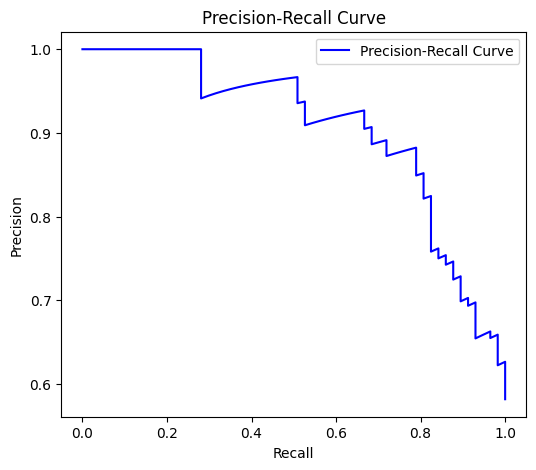

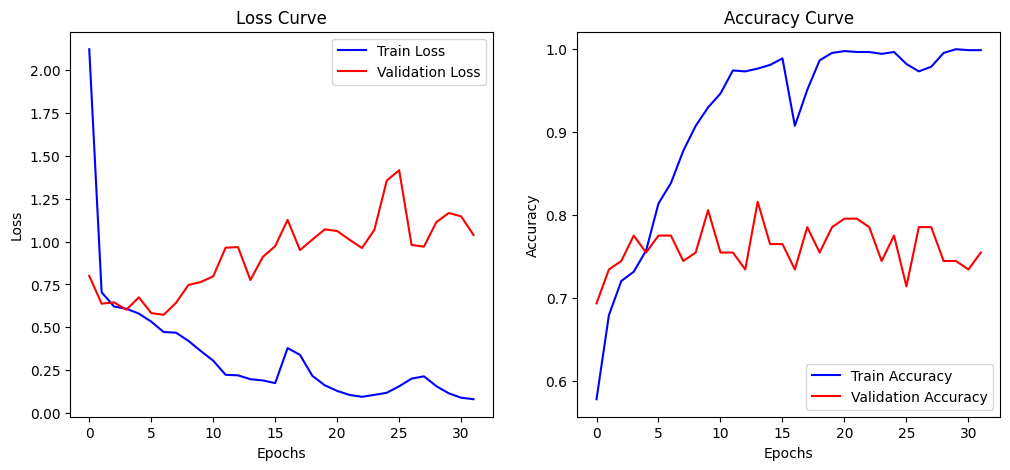

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━

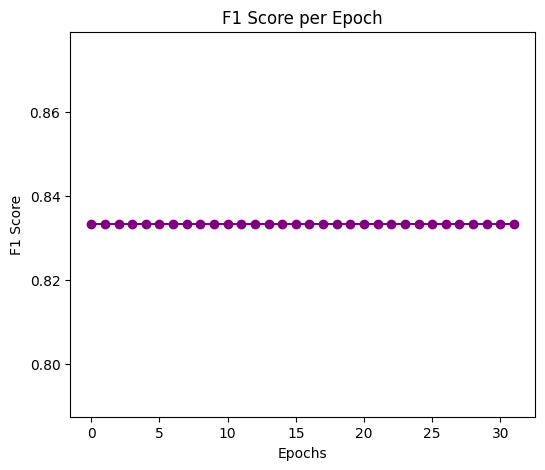

Cohen’s Kappa Score: 0.63
Matthews Correlation Coefficient (MCC): 0.64


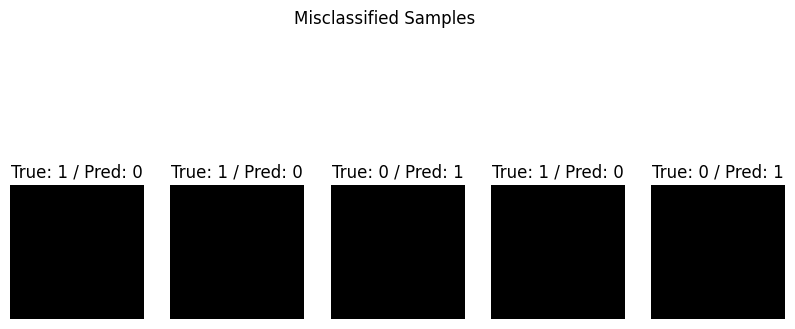


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8163
Precision 0.8824
   Recall 0.7895
 F1-score 0.8333
      AUC 0.8605
      MCC 0.6350
   G-mean 0.8209


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn+SE**

In [3]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  # Resize to 128x128
        img = img / 255.0  # Normalize pixel values
        images.append(img)
        labels.append(label)  # Assign the given label (0 or 1)
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Squeeze and Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    """Squeeze and Excitation block to enhance feature representation"""
    filters = input_tensor.shape[-1]
    
    # Squeeze operation
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    
    # Excitation operation (Rescale feature maps)
    se = layers.Reshape((1, 1, filters))(se)
    output_tensor = layers.multiply([input_tensor, se])
    return output_tensor

# Define CNN Model with SE Attention
def build_se_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with Residual Connection and SE
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.Add()([x, res])  # Residual Connection
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)  # Apply SE block
    x = layers.MaxPooling2D((2, 2))(x)

    # Global Average Pooling instead of Flatten
    x = layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layer
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)

    # Output Layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Define Model
    model = models.Model(inputs, outputs)

    # Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # Compile Model
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_se_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_se_cnn.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_se_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn+SE_model.keras")
print("Model saved successfully in /kaggle/working/")


Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 373ms/step - accuracy: 0.6432 - loss: 3.6047 - val_accuracy: 0.4184 - val_loss: 2.4313
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7031 - loss: 2.0312 - val_accuracy: 0.4184 - val_loss: 1.5835
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7070 - loss: 1.2577 - val_accuracy: 0.4184 - val_loss: 1.1638
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7608 - loss: 0.8851 - val_accuracy: 0.4184 - val_loss: 1.0567
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7476 - loss: 0.6921 - val_accuracy: 0.5816 - val_loss: 0.8168
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7803 - loss: 0.5856 - val_accuracy: 0.5816 - val_loss: 0.7811
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7896 - loss: 0.5240 - val_accuracy: 0.5816 - val_loss: 0.9359
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7965 - loss: 0.4960 - val_accuracy: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 351ms/step


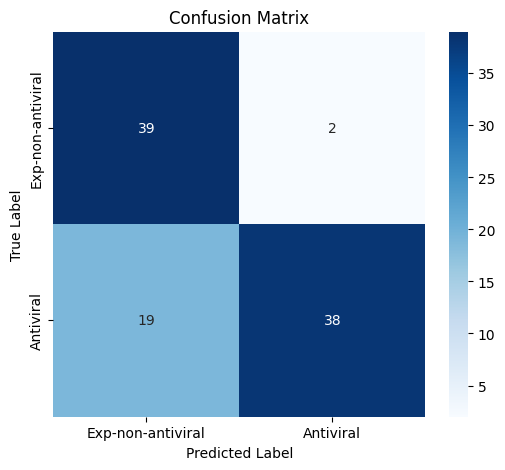


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.67      0.95      0.79        41
        Antiviral       0.95      0.67      0.78        57

         accuracy                           0.79        98
        macro avg       0.81      0.81      0.79        98
     weighted avg       0.83      0.79      0.79        98



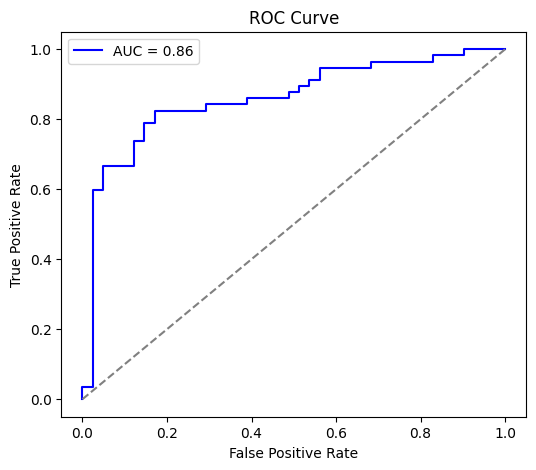

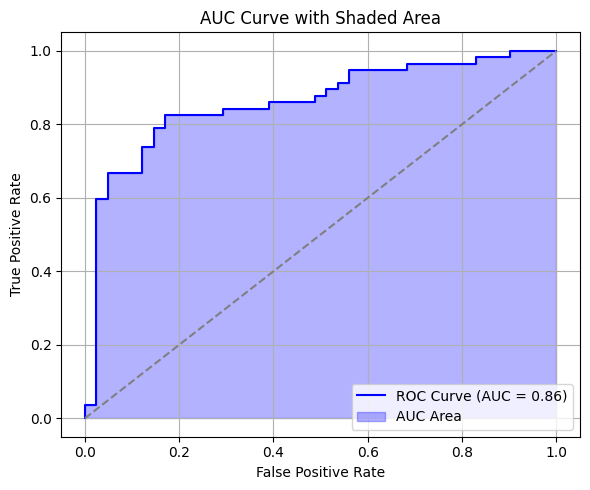

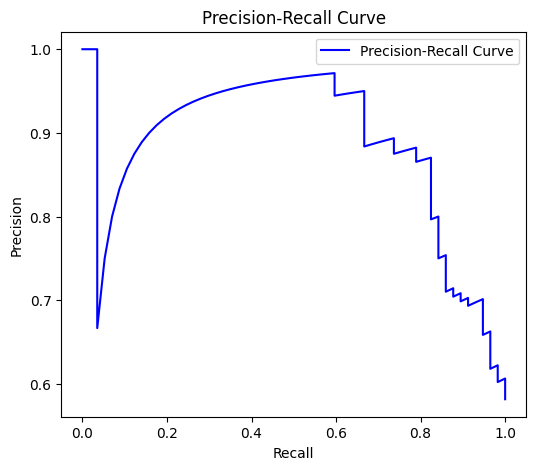

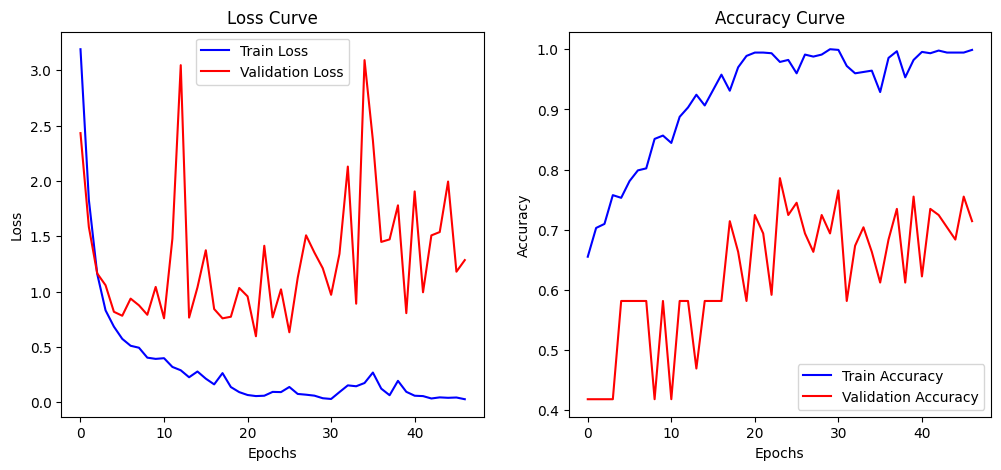

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━

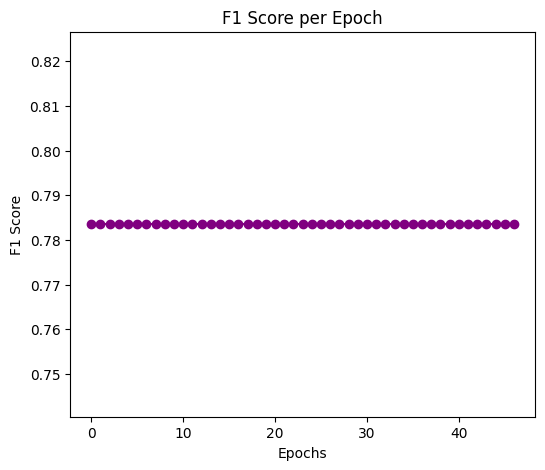

Cohen’s Kappa Score: 0.58
Matthews Correlation Coefficient (MCC): 0.62


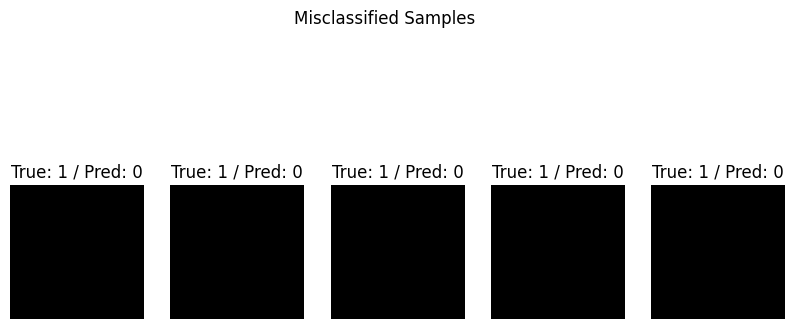


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.7857
Precision 0.9500
   Recall 0.6667
 F1-score 0.7835
      AUC 0.8596
      MCC 0.6201
   G-mean 0.7963


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn+CBAM**

In [5]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"


# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# CBAM Attention Mechanism
def cbam_block(input_tensor, reduction_ratio=16):
    """Convolutional Block Attention Module (CBAM)"""
    filters = input_tensor.shape[-1]

    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    max_pool = layers.GlobalMaxPooling2D()(input_tensor)

    shared_dense = layers.Dense(filters // reduction_ratio, activation="relu")
    avg_out = shared_dense(avg_pool)
    max_out = shared_dense(max_pool)

    # 🔹 Correct: Ensure output matches input channels
    shared_dense_2 = layers.Dense(filters, activation="sigmoid")  # Map back to `filters`
    avg_out = shared_dense_2(avg_out)
    max_out = shared_dense_2(max_out)

    avg_out = layers.Reshape((1, 1, filters))(avg_out)
    max_out = layers.Reshape((1, 1, filters))(max_out)

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    
    x = layers.Multiply()([input_tensor, channel_attention])

    # Spatial Attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
    spatial_attention = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(spatial_attention)
    
    output_tensor = layers.Multiply()([x, spatial_attention])
    return output_tensor



# Define CNN Model with CBAM
def build_cbam_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with Residual Connection and CBAM
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.Add()([x, res])  
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)  
    x = layers.MaxPooling2D((2, 2))(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layer
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)

    # Output Layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Define Model
    model = models.Model(inputs, outputs)

    # Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    # Compile Model
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate model
model = build_cbam_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cbam_cnn.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cbam_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_cnn+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")


Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 443ms/step - accuracy: 0.6101 - loss: 3.5567 - val_accuracy: 0.4184 - val_loss: 2.2669
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6868 - loss: 1.8679 - val_accuracy: 0.4184 - val_loss: 1.4220
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7357 - loss: 1.0816 - val_accuracy: 0.4184 - val_loss: 1.1245
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7871 - loss: 0.7228 - val_accuracy: 0.4184 - val_loss: 1.0128
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8333 - loss: 0.5321 - val_accuracy: 0.4184 - val_loss: 1.0796
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8502 - loss: 0.4617 - val_accuracy: 0.4184 - val_loss: 1.0687
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8594 - loss: 0.4078 - val_accuracy: 0.4184 - val_loss: 0.8944
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8806 - loss: 0.3527 - val_accuracy: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 596ms/step


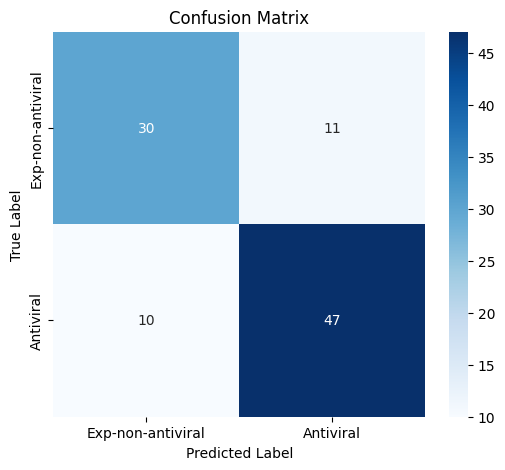


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.75      0.73      0.74        41
        Antiviral       0.81      0.82      0.82        57

         accuracy                           0.79        98
        macro avg       0.78      0.78      0.78        98
     weighted avg       0.79      0.79      0.79        98



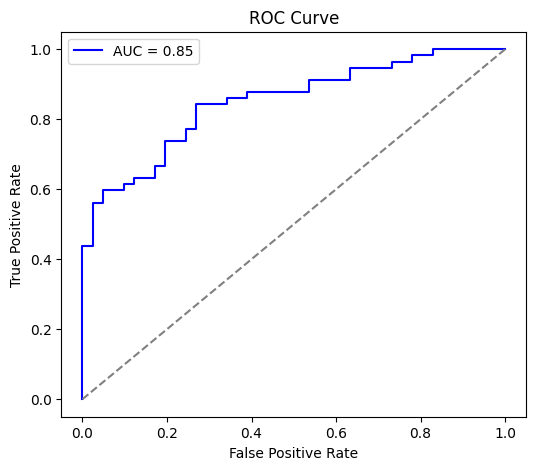

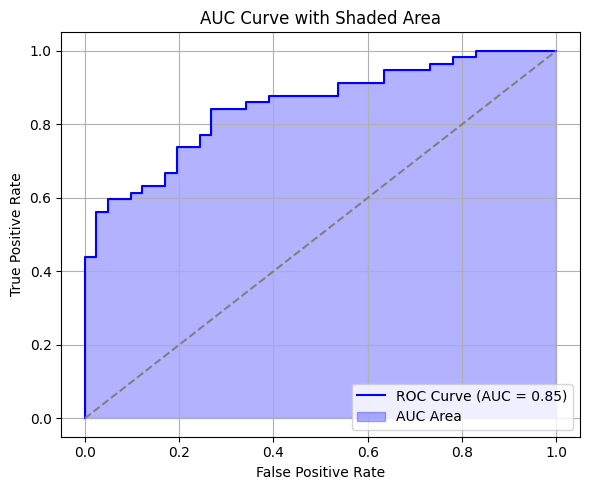

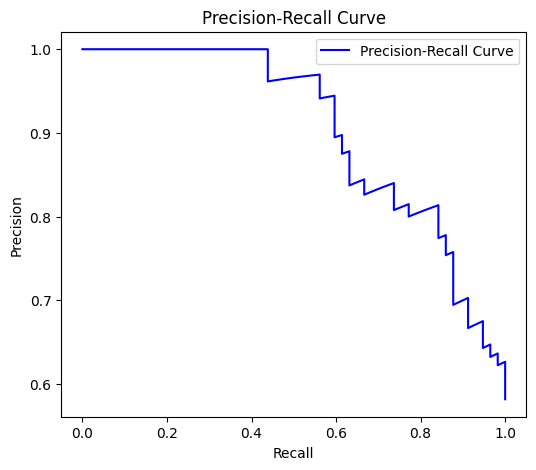

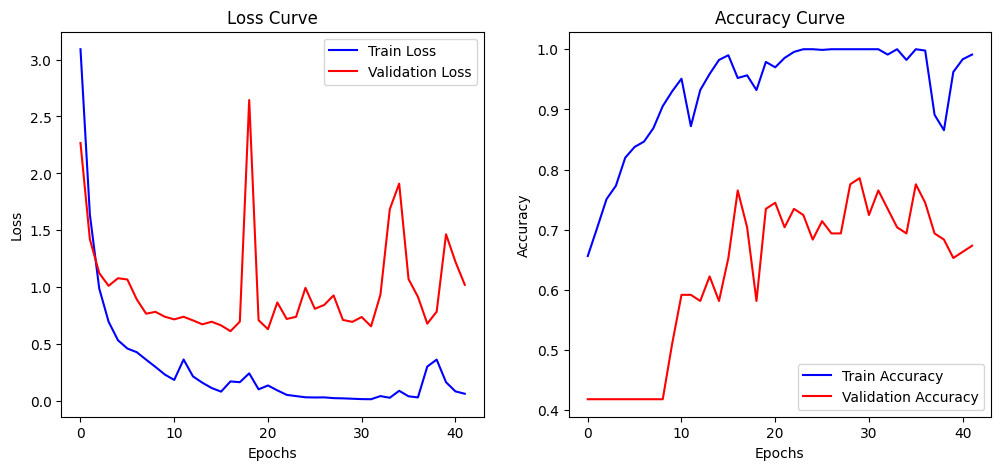

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━

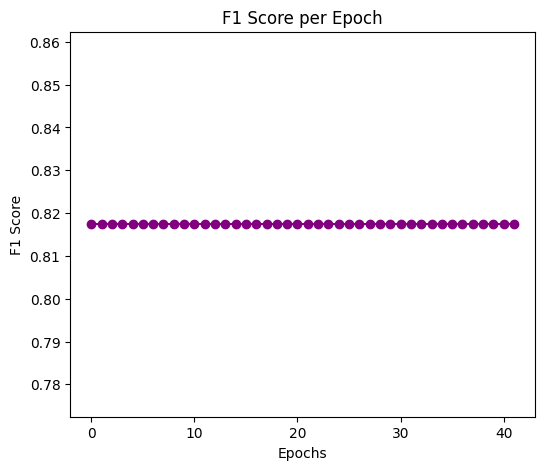

Cohen’s Kappa Score: 0.56
Matthews Correlation Coefficient (MCC): 0.56


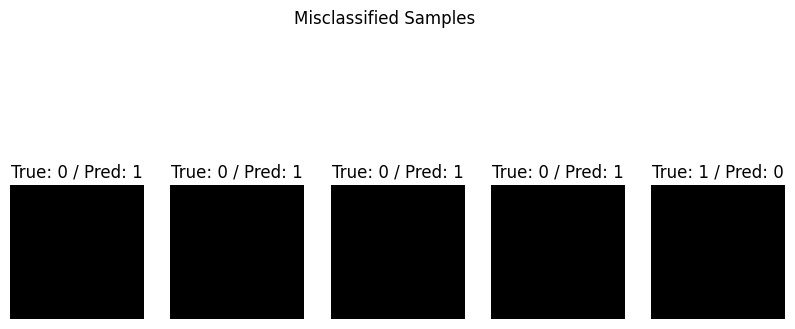


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.7857
Precision 0.8103
   Recall 0.8246
 F1-score 0.8174
      AUC 0.8494
      MCC 0.5583
   G-mean 0.7767


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet50**

In [7]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Paths to directories (Keep the same dataset paths)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"
# Image dimensions for ResNet50
IMG_HEIGHT, IMG_WIDTH = 224, 224  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Build ResNet50 Model (Without SE Attention)
def build_resnet_model(input_shape):
    base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers, fine-tune last layers
    for layer in base_model.layers[:140]:  
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Global Pooling & Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate ResNet Model
model = build_resnet_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_model.keras", monitor='val_accuracy', save_best_only=True)

# Train Model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_resnet_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50_model.keras")
print("Model saved successfully in /kaggle/working/")



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 50s 722ms/step - accuracy: 0.6026 - loss: 5.2955 - val_accuracy: 0.4184 - val_loss: 5.1996
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.7225 - loss: 4.8903 - val_accuracy: 0.4184 - val_loss: 4.8910
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.7567 - loss: 4.5668 - val_accuracy: 0.4184 - val_loss: 4.6092
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.7952 - loss: 4.3098 - val_accuracy: 0.5918 - val_loss: 4.3597
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - accuracy: 0.7687 - loss: 4.1323 - val_accuracy: 0.7245 - val_loss: 4.1586
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.8300 - loss: 3.8488 - val_accuracy: 0.6939 - val_loss: 3.9537
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.8324 - loss: 3.7234 - val_accuracy: 0.5816 - val_loss: 3.9196
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 152

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


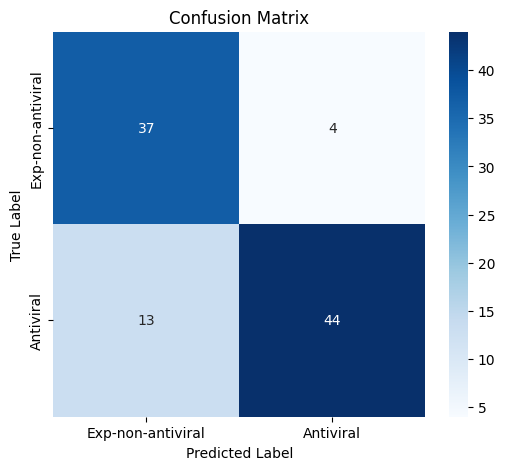


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.74      0.90      0.81        41
        Antiviral       0.92      0.77      0.84        57

         accuracy                           0.83        98
        macro avg       0.83      0.84      0.83        98
     weighted avg       0.84      0.83      0.83        98



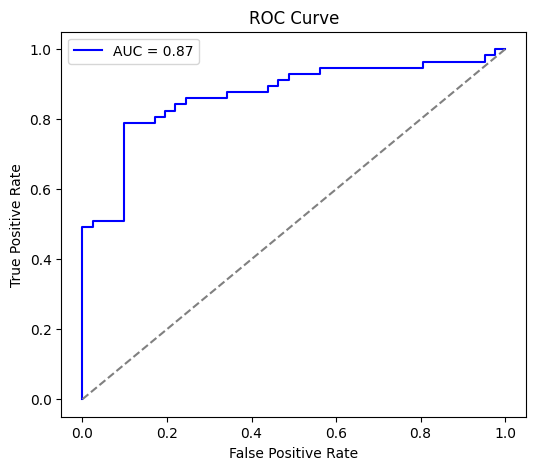

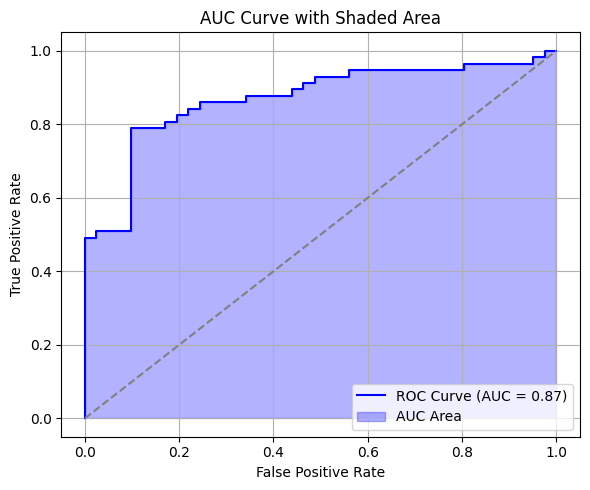

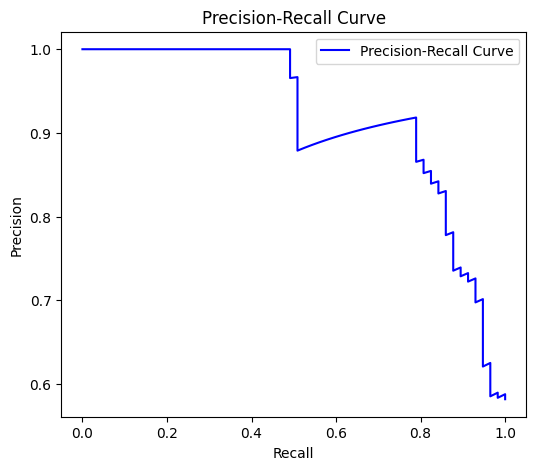

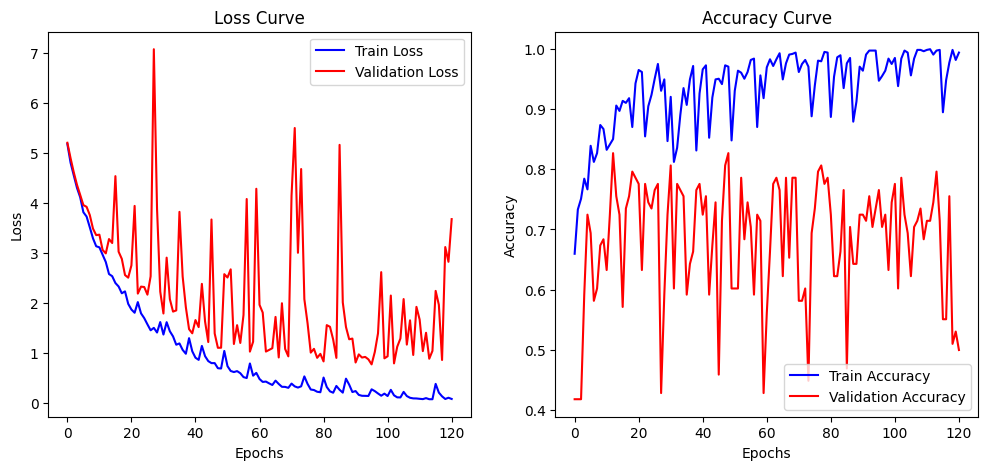

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━

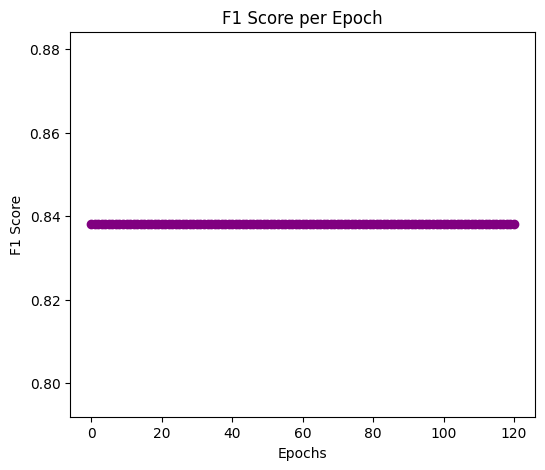

Cohen’s Kappa Score: 0.65
Matthews Correlation Coefficient (MCC): 0.67


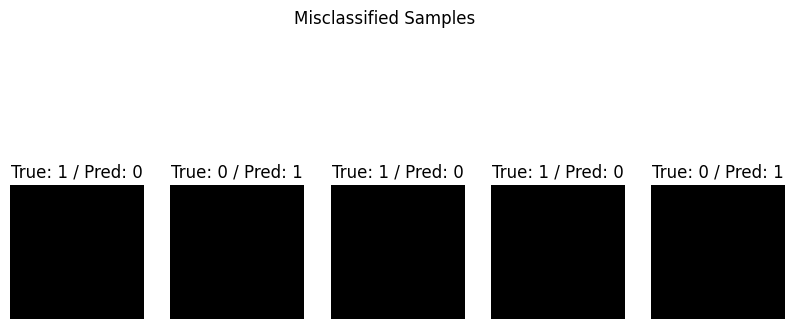


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8265
Precision 0.9167
   Recall 0.7719
 F1-score 0.8381
      AUC 0.8695
      MCC 0.6655
   G-mean 0.8346


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet50 +SE**

In [9]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Paths to directories (Keep the same dataset paths)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"

# Image dimensions for ResNet50
IMG_HEIGHT, IMG_WIDTH = 224, 224  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Squeeze and Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]  
    se = layers.GlobalAveragePooling2D()(input_tensor)  
    se = layers.Dense(filters // ratio, activation='relu')(se)  
    se = layers.Dense(filters, activation='sigmoid')(se)  
    se = layers.Reshape((1, 1, filters))(se)  
    return layers.Multiply()([input_tensor, se])  

# Build ResNet50 Model with SE Attention
def build_resnet_model(input_shape):
    base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze the lower ResNet layers
    for layer in base_model.layers[:140]:  # Fine-tune last layers
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # SE Attention Block
    x = squeeze_excite_block(x)

    # Global Pooling & Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate ResNet Model
model = build_resnet_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_model.keras", monitor='val_accuracy', save_best_only=True)

# Train Model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_resnet_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50+SE_model.keras")
print("Model saved successfully in /kaggle/working/")



Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 45s 694ms/step - accuracy: 0.6212 - loss: 5.2678 - val_accuracy: 0.5816 - val_loss: 5.0124
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.7574 - loss: 4.8221 - val_accuracy: 0.5816 - val_loss: 4.7878
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.7635 - loss: 4.5722 - val_accuracy: 0.6327 - val_loss: 4.5727
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.8024 - loss: 4.2623 - val_accuracy: 0.5714 - val_loss: 4.3647
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.8186 - loss: 4.0429 - val_accuracy: 0.5612 - val_loss: 4.1580
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - accuracy: 0.8327 - loss: 3.7986 - val_accuracy: 0.7755 - val_loss: 3.9210
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.8431 - loss: 3.5888 - val_accuracy: 0.7041 - val_loss: 3.7099
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.8626 - loss: 3.3819 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step  


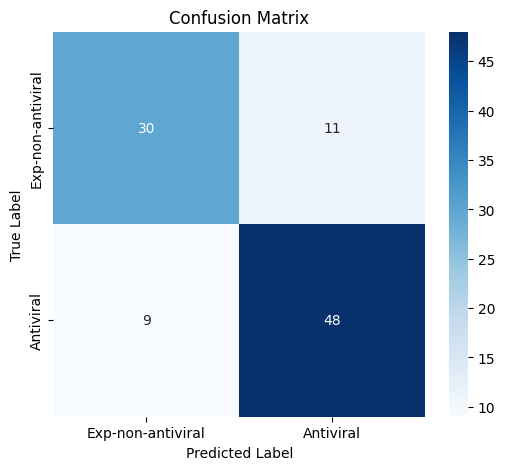


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.77      0.73      0.75        41
        Antiviral       0.81      0.84      0.83        57

         accuracy                           0.80        98
        macro avg       0.79      0.79      0.79        98
     weighted avg       0.80      0.80      0.80        98



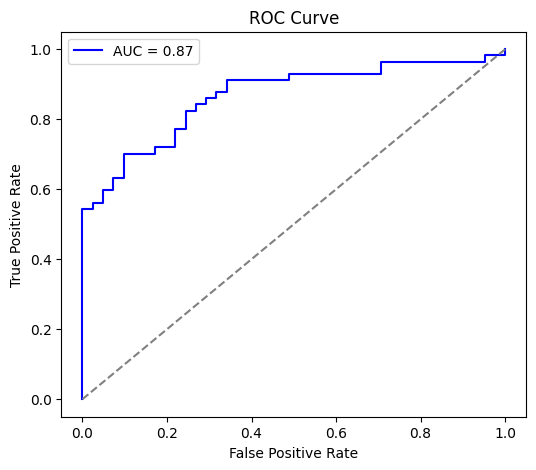

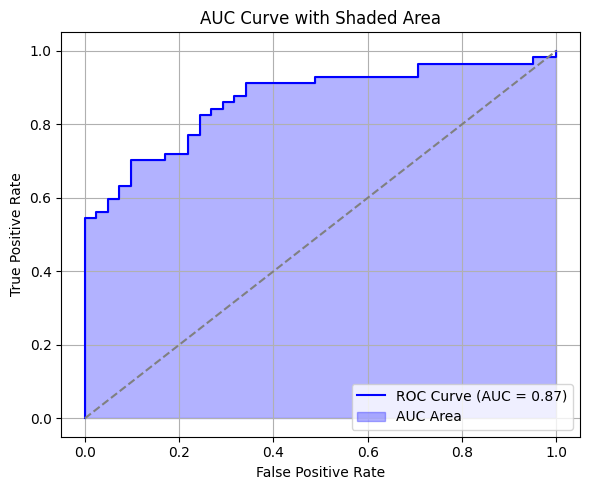

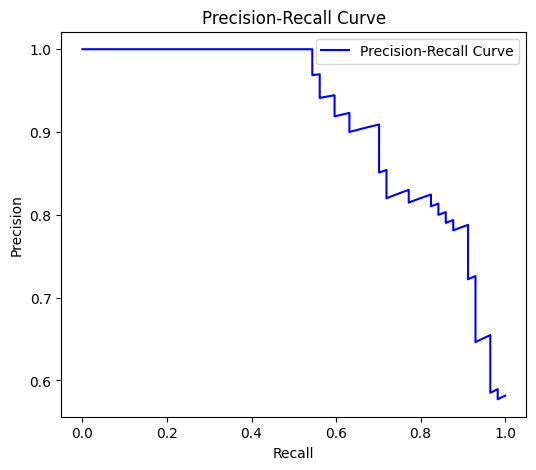

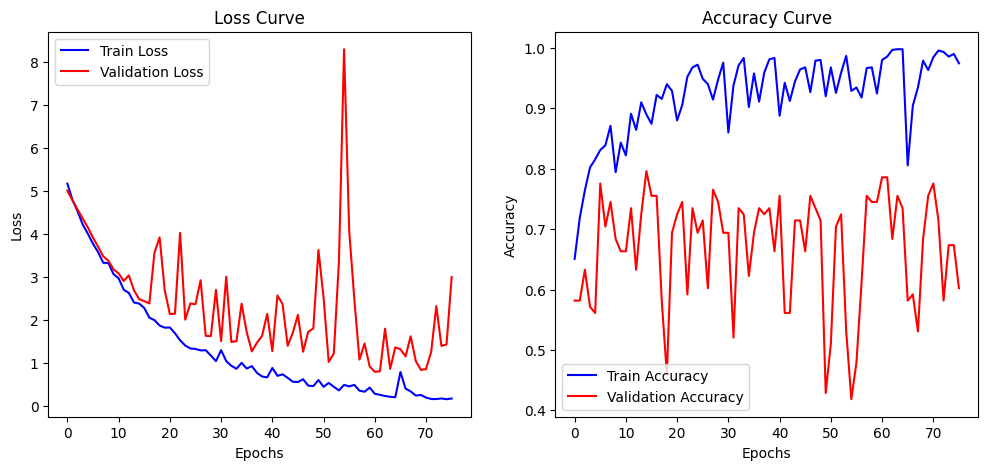

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━

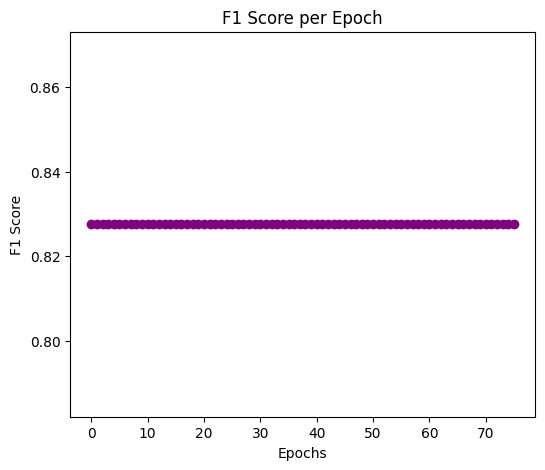

Cohen’s Kappa Score: 0.58
Matthews Correlation Coefficient (MCC): 0.58


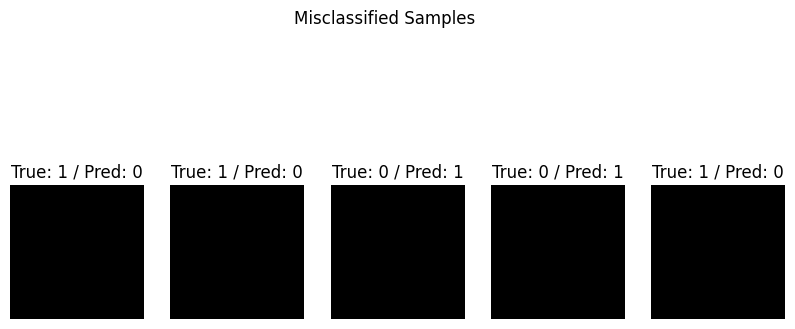


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.7959
Precision 0.8136
   Recall 0.8421
 F1-score 0.8276
      AUC 0.8661
      MCC 0.5783
   G-mean 0.7850


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet 50 + CBAM**

In [11]:
import os
import numpy as npa
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Reshape, Multiply,
    Conv2D, Add, Activation, Lambda, Dropout
)
from tensorflow.keras import backend as K

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"

# Image dimensions and parameters
IMG_HEIGHT, IMG_WIDTH = 224, 224  # ResNet50 expects 224x224 images

# Function to load and preprocess images for a given class
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  # Resize to ResNet input size
        img = preprocess_input(img)  # Normalize using ResNet's preprocess function
        images.append(img)
        labels.append(label)  # Assign the given label (0 or 1)
    return np.array(images), np.array(labels)

# Load training and testing datasets for both classes
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes into a single dataset
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset to avoid order bias
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
)

# CBAM Attention Mechanism
def cbam_block(input_tensor, ratio=8):
    """Convolutional Block Attention Module (CBAM)"""
    
    # 🔹 Channel Attention
    channel_avg = GlobalAveragePooling2D()(input_tensor)
    channel_max = GlobalMaxPooling2D()(input_tensor)
    
    channel_avg = Dense(input_tensor.shape[-1] // ratio, activation='relu')(channel_avg)
    channel_avg = Dense(input_tensor.shape[-1], activation='sigmoid')(channel_avg)
    
    channel_max = Dense(input_tensor.shape[-1] // ratio, activation='relu')(channel_max)
    channel_max = Dense(input_tensor.shape[-1], activation='sigmoid')(channel_max)
    
    channel_att = Add()([channel_avg, channel_max])
    channel_att = Activation('sigmoid')(channel_att)
    channel_att = Reshape((1, 1, input_tensor.shape[-1]))(channel_att)
    channel_refined = Multiply()([input_tensor, channel_att])

    # 🔹 Spatial Attention
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    
    spatial_att = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(Add()([avg_pool, max_pool]))
    spatial_refined = Multiply()([channel_refined, spatial_att])

    return spatial_refined

# Define ResNet50-based Model with CBAM
def build_resnet_cbam_model(input_shape):
    # Load pretrained ResNet50 model (excluding the top classification layer)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers (up to conv4_block6, modify as needed for fine-tuning)
    for layer in base_model.layers[:143]:  # Freezes earlier layers
        layer.trainable = False
    for layer in base_model.layers[143:]:  # Fine-tune last few layers
        layer.trainable = True

    # Apply CBAM Attention
    x = cbam_block(base_model.output)

    # Custom classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    # Build and compile the model
    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile model with Adam optimizer and adaptive learning rate
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate model with CBAM
model = build_resnet_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks for early stopping and model checkpointing
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_cbam_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_resnet_cbam_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 695ms/step - accuracy: 0.6593 - loss: 8.6534 - val_accuracy: 0.5510 - val_loss: 8.2288
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.7748 - loss: 7.8156 - val_accuracy: 0.5816 - val_loss: 7.6147
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.8207 - loss: 7.0996 - val_accuracy: 0.5510 - val_loss: 7.6317
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - accuracy: 0.8325 - loss: 6.4730 - val_accuracy: 0.6939 - val_loss: 6.4878
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.8438 - loss: 5.9272 - val_accuracy: 0.6837 - val_loss: 5.8185
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.9007 - loss: 5.3332 - val_accuracy: 0.7347 - val_loss: 5.6521
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.9157 - loss: 4.8393 - val_accuracy: 0.7347 - val_loss: 5.2155
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.9153 - loss: 4.4109 - val_acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


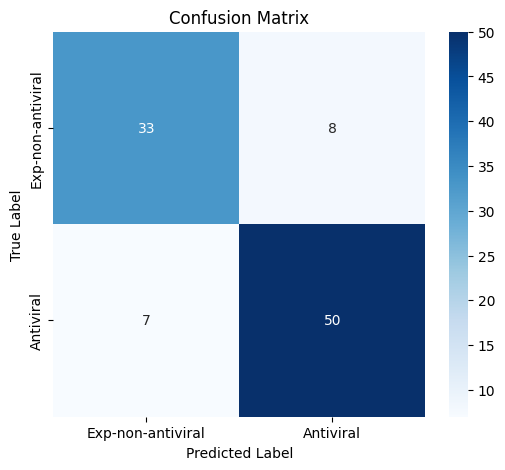


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.82      0.80      0.81        41
        Antiviral       0.86      0.88      0.87        57

         accuracy                           0.85        98
        macro avg       0.84      0.84      0.84        98
     weighted avg       0.85      0.85      0.85        98



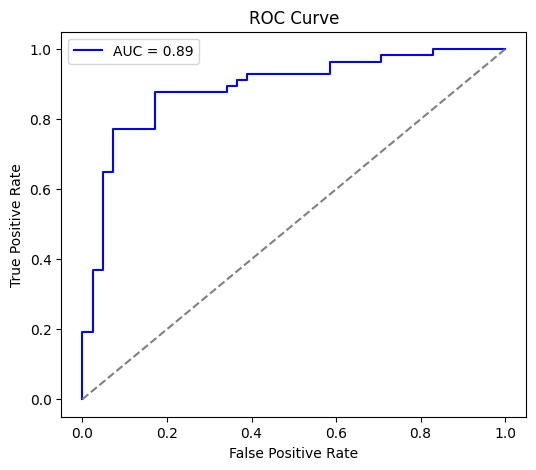

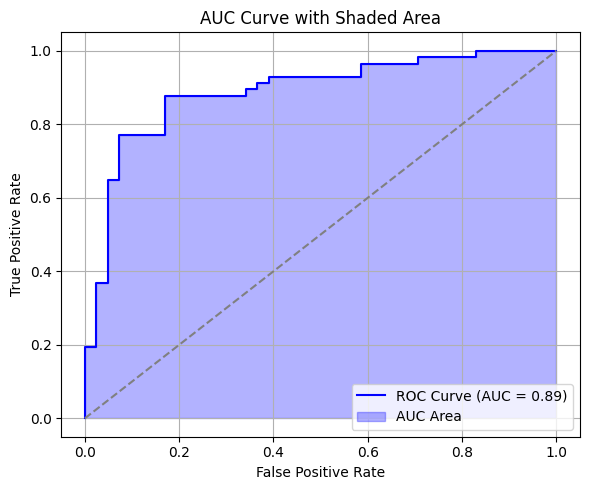

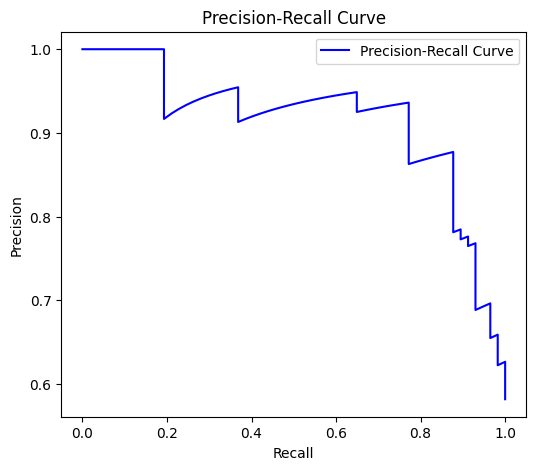

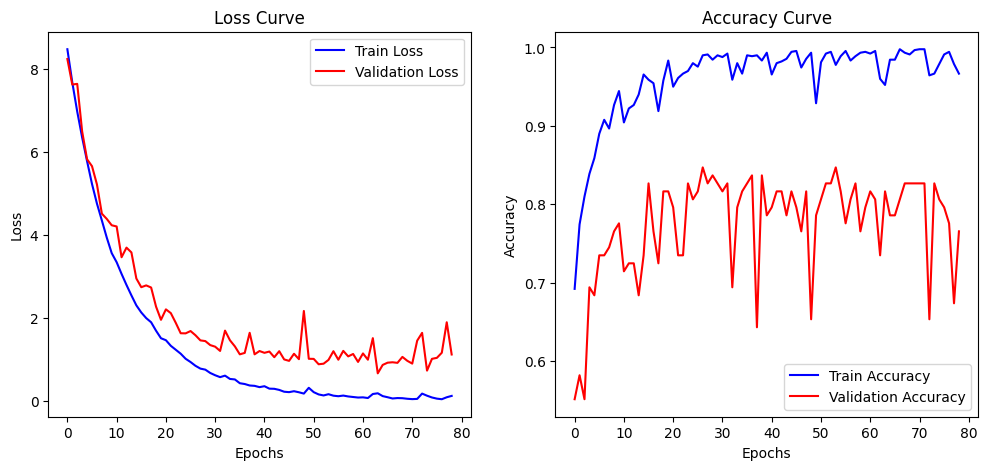

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━

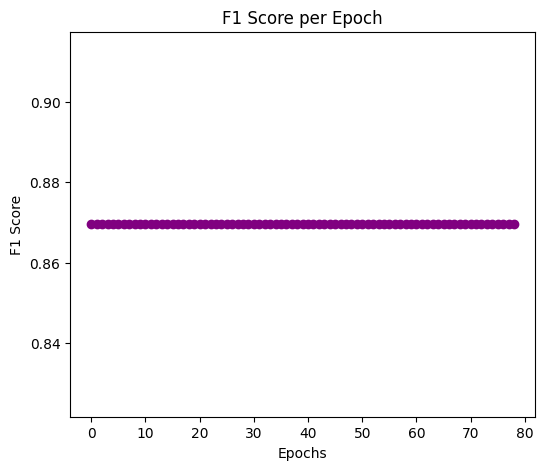

Cohen’s Kappa Score: 0.68
Matthews Correlation Coefficient (MCC): 0.68


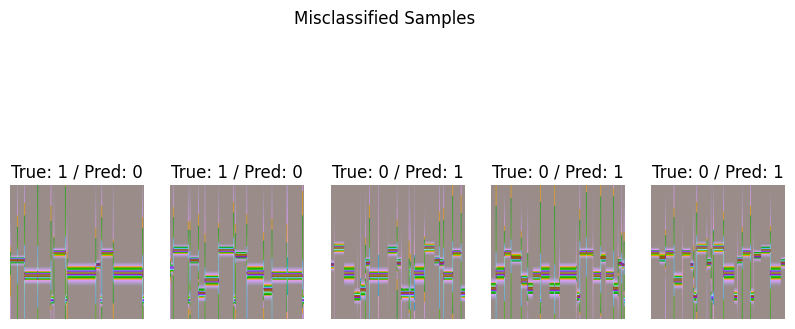


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8469
Precision 0.8621
   Recall 0.8772
 F1-score 0.8696
      AUC 0.8883
      MCC 0.6846
   G-mean 0.8403


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3**

In [1]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Paths to directories (Keep the same dataset paths)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"

# Image dimensions for InceptionV3
IMG_HEIGHT, IMG_WIDTH = 299, 299  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load training and testing datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine both classes
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Build InceptionV3 Model (Replacing ResNet50)
def build_inception_model(input_shape):
    base_model = applications.InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers, fine-tune last layers
    for layer in base_model.layers[:280]:  
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)

    # Global Pooling & Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=5000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer, 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Instantiate InceptionV3 Model
model = build_inception_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train Model
history = model.fit(
    X_train, y_train, batch_size=32, epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3_model.keras")
print("Model saved successfully in /kaggle/working/")



2025-05-25 12:32:21.729820: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748176342.158893      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748176342.285888      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1748176401.250028      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748176401.250752      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200


I0000 00:00:1748176423.466971      97 service.cc:148] XLA service 0x79d548003460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748176423.468994      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748176423.469025      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748176425.887083      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/29 ━━━━━━━━━━━━━━━━━━━━ 14:51 32s/step - accuracy: 0.4688 - loss: 5.6436

I0000 00:00:1748176439.746108      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/29 ━━━━━━━━━━━━━━━━━━━━ 58s 931ms/step - accuracy: 0.5933 - loss: 5.4237 - val_accuracy: 0.6735 - val_loss: 5.0231
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.7679 - loss: 4.8688 - val_accuracy: 0.7347 - val_loss: 4.8544
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.7746 - loss: 4.6728 - val_accuracy: 0.7857 - val_loss: 4.6567
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.8777 - loss: 4.4030 - val_accuracy: 0.8061 - val_loss: 4.4999
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.8873 - loss: 4.2062 - val_accuracy: 0.7143 - val_loss: 4.3878
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.9302 - loss: 4.0196 - val_accuracy: 0.7449 - val_loss: 4.2756
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.9243 - loss: 3.8605 - val_accuracy: 0.7551 - val_loss: 4.0702
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9497 - loss: 3.6781 - val_accuracy: 0.806

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step 


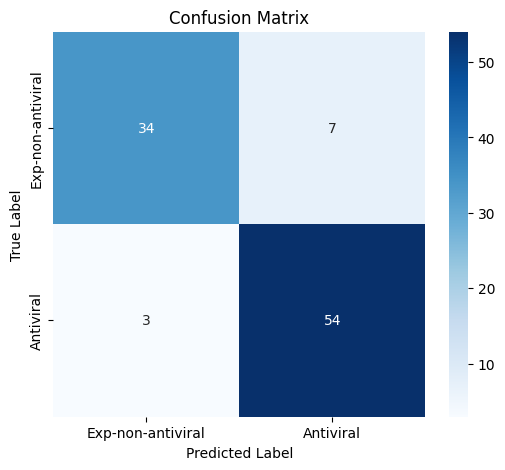


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.92      0.83      0.87        41
        Antiviral       0.89      0.95      0.92        57

         accuracy                           0.90        98
        macro avg       0.90      0.89      0.89        98
     weighted avg       0.90      0.90      0.90        98



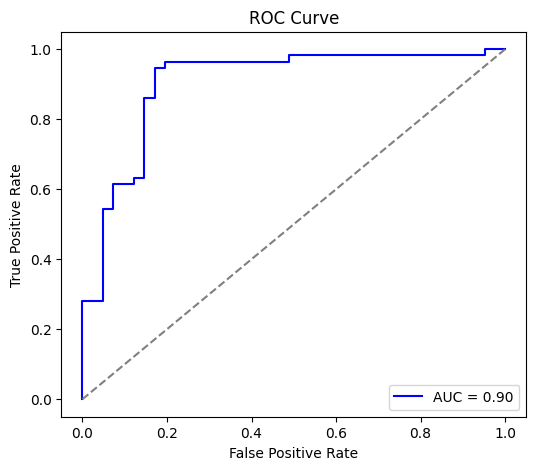

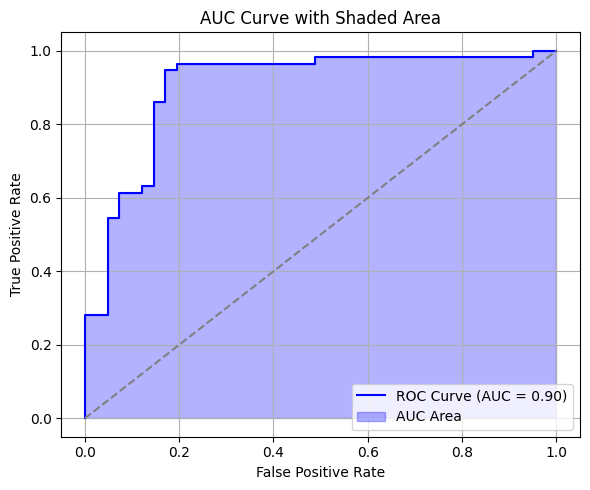

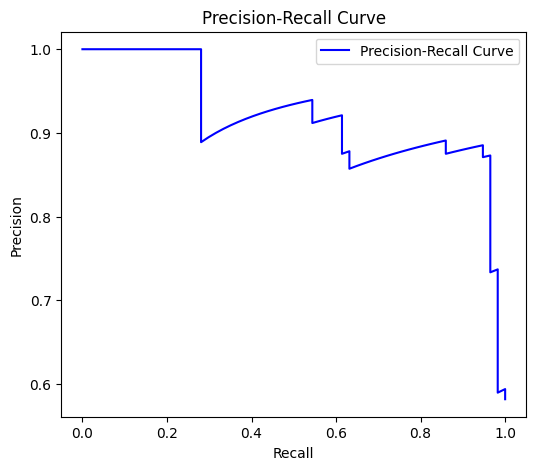

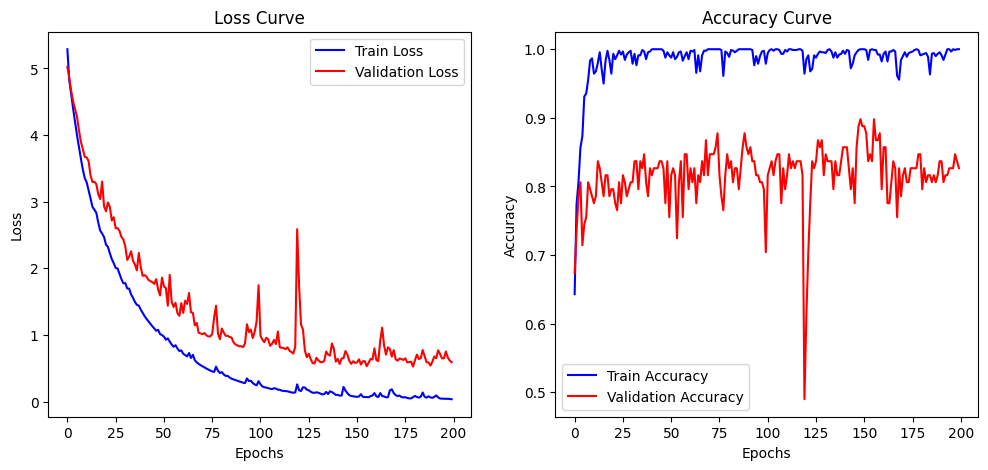

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 

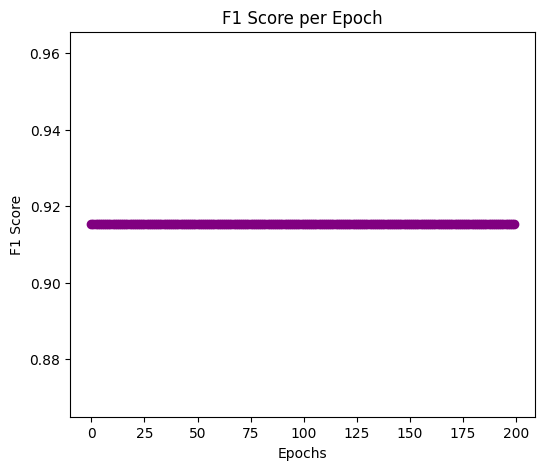

Cohen’s Kappa Score: 0.79
Matthews Correlation Coefficient (MCC): 0.79


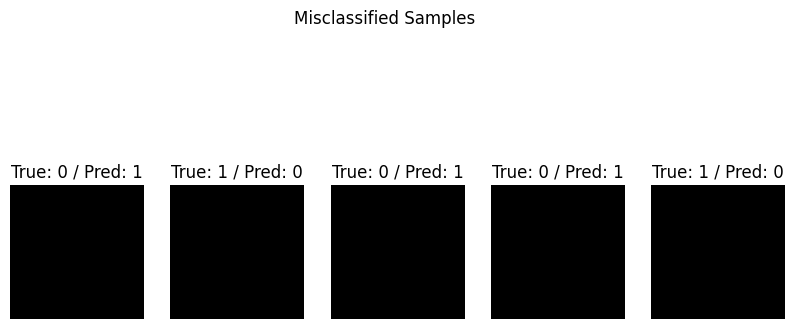


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8980
Precision 0.8852
   Recall 0.9474
 F1-score 0.9153
      AUC 0.9029
      MCC 0.7903
   G-mean 0.8864


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3 + SE**

In [3]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Paths to directories (Modify these paths based on your dataset location)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"


# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299  # InceptionV3 input size

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = preprocess_input(img)  
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load datasets
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine datasets
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle datasets
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# Squeeze-and-Excitation (SE) Attention Block
def se_block(input_tensor, ratio=16):
    """Squeeze-and-Excitation Block"""
    channel = input_tensor.shape[-1]

    # Squeeze: Global Average Pooling
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(channel // ratio, activation='relu')(se)  # Bottleneck
    se = layers.Dense(channel, activation='sigmoid')(se)  # Excitation

    se = layers.Reshape((1, 1, channel))(se)  # Reshape for broadcasting
    x = layers.Multiply()([input_tensor, se])  # Apply channel attention
    return x

# Define InceptionV3 Model with SE Attention
def build_inception_se_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze first layers
    for layer in base_model.layers[:249]:  
        layer.trainable = False
    for layer in base_model.layers[249:]:  
        layer.trainable = True

    # Apply SE Attention to last convolutional block
    x = se_block(base_model.output)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile Model with Exponential Decay Learning Rate
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate model with SE Attention
model = build_inception_se_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_se_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate Model
model.load_weights("best_se_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with SE Attention: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3+SE_model.keras")
print("Model saved successfully in /kaggle/working/")



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.6481 - loss: 8.9057 - val_accuracy: 0.6429 - val_loss: 8.4819
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step - accuracy: 0.7510 - loss: 8.3408 - val_accuracy: 0.6327 - val_loss: 8.1599
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 295ms/step - accuracy: 0.7716 - loss: 7.9267 - val_accuracy: 0.6939 - val_loss: 7.8563
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.8033 - loss: 7.5460 - val_accuracy: 0.6327 - val_loss: 7.5146
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.8727 - loss: 7.1792 - val_accuracy: 0.6429 - val_loss: 7.2218
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 292ms/step - accuracy: 0.8769 - loss: 6.8503 - val_accuracy: 0.7551 - val_loss: 6.8928
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.8886 - loss: 6.5228 - val_accuracy: 0.6122 - val_loss: 6.8017
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - accuracy: 0.9004 - loss: 6.2630 - val_accura

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step 


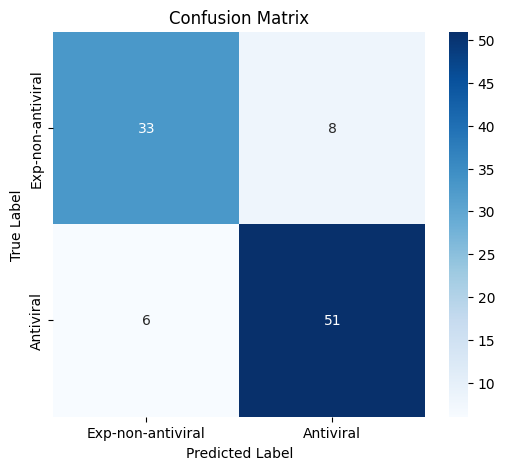


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.85      0.80      0.83        41
        Antiviral       0.86      0.89      0.88        57

         accuracy                           0.86        98
        macro avg       0.86      0.85      0.85        98
     weighted avg       0.86      0.86      0.86        98



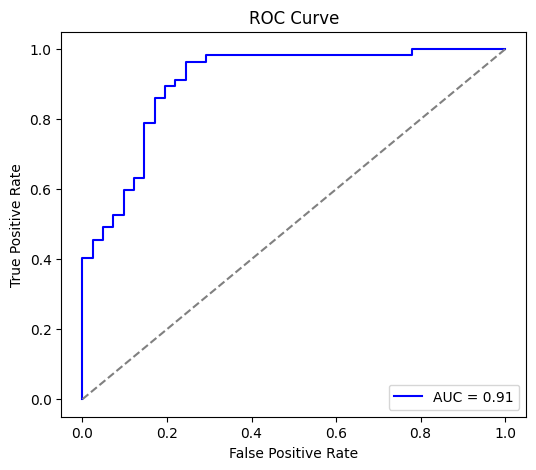

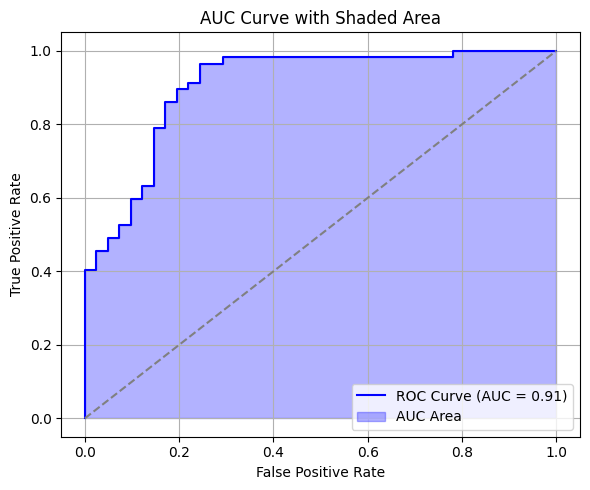

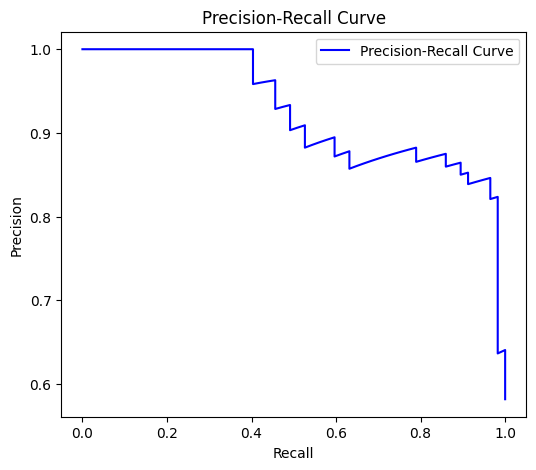

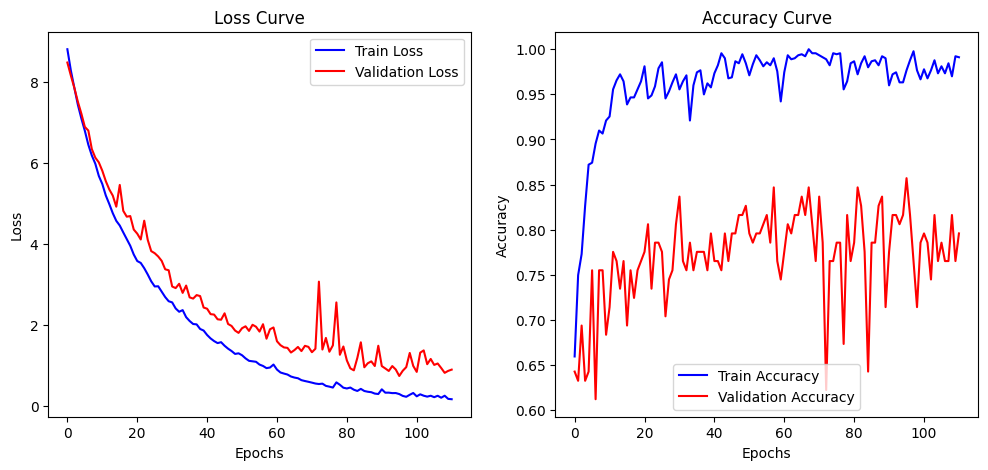

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 

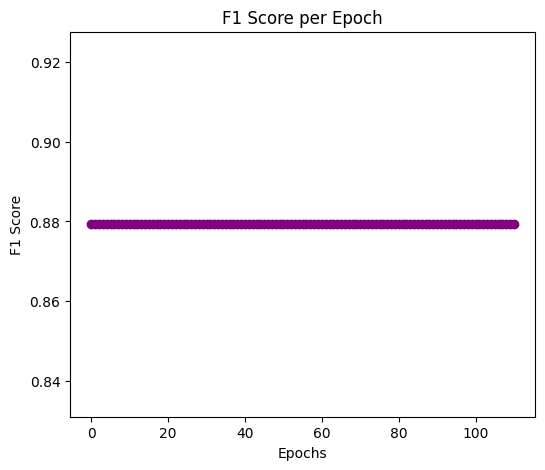

Cohen’s Kappa Score: 0.70
Matthews Correlation Coefficient (MCC): 0.71


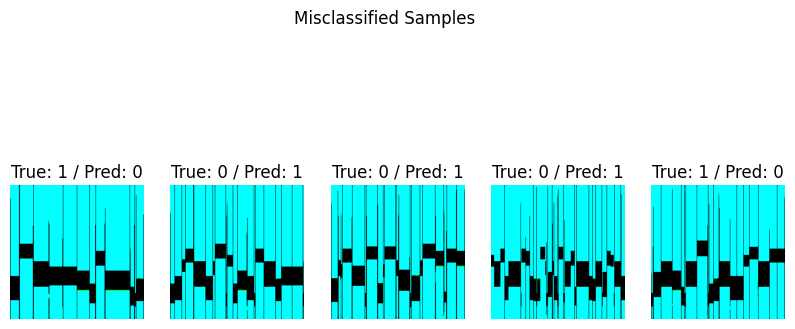


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8571
Precision 0.8644
   Recall 0.8947
 F1-score 0.8793
      AUC 0.9059
      MCC 0.7051
   G-mean 0.8486


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3 + CBAM**

In [5]:
import os


import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Paths to dataset (Modify based on your setup)
data_dir_train_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral training images"
data_dir_test_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/antiviral testing images"
,
data_dir_train_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral training images"
data_dir_test_non_antiviral = "/kaggle/input/spectrogram-images-rhythm-dynamics-ennavia-a/spectrogram images/exp-non-antiviral testing images"

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299  # InceptionV3 expects 299x299 images

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = preprocess_input(img)  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load dataset
X_train_antiviral, y_train_antiviral = load_images_from_directory(data_dir_train_antiviral, label=1)
X_test_antiviral, y_test_antiviral = load_images_from_directory(data_dir_test_antiviral, label=1)

X_train_non_antiviral, y_train_non_antiviral = load_images_from_directory(data_dir_train_non_antiviral, label=0)
X_test_non_antiviral, y_test_non_antiviral = load_images_from_directory(data_dir_test_non_antiviral, label=0)

# Combine datasets
X_train = np.concatenate((X_train_antiviral, X_train_non_antiviral), axis=0)
y_train = np.concatenate((y_train_antiviral, y_train_non_antiviral), axis=0)

X_test = np.concatenate((X_test_antiviral, X_test_non_antiviral), axis=0)
y_test = np.concatenate((y_test_antiviral, y_test_non_antiviral), axis=0)

# Shuffle dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# Data Augmentation
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True, brightness_range=[0.8, 1.2])

# CBAM Attention Block
def cbam_block(feature_map, ratio=8):
    """CBAM Attention Mechanism"""
    
    # **Channel Attention**
    channel_avg = layers.GlobalAveragePooling2D()(feature_map)
    channel_max = layers.GlobalMaxPooling2D()(feature_map)
    channel_concat = layers.Concatenate()([channel_avg, channel_max])
    
    channel_dense = layers.Dense(feature_map.shape[-1] // ratio, activation='relu')(channel_concat)
    channel_dense = layers.Dense(feature_map.shape[-1], activation='sigmoid')(channel_dense)
    
    channel_dense = layers.Reshape((1, 1, feature_map.shape[-1]))(channel_dense)  # Reshape for broadcasting
    channel_attention = layers.Multiply()([feature_map, channel_dense])  # Multiply with feature map
    
    # **Spatial Attention**
    spatial_avg = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_attention)
    spatial_max = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_attention)
    spatial_concat = layers.Concatenate(axis=-1)([spatial_avg, spatial_max])
    
    spatial_attention = layers.Conv2D(1, kernel_size=7, activation='sigmoid', padding='same')(spatial_concat)
    spatial_attention = layers.Multiply()([channel_attention, spatial_attention])
    
    return spatial_attention

# Define InceptionV3 Model with CBAM
def build_inception_cbam_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze initial layers (up to mixed6, modify as needed for fine-tuning)
    for layer in base_model.layers[:249]:  
        layer.trainable = False
    for layer in base_model.layers[249:]:  
        layer.trainable = True

    # Apply CBAM Attention
    x = cbam_block(base_model.output)

    # Custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    
    # Compile model
    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Instantiate model with CBAM
model = build_inception_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cbam_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cbam_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

# Save model in Kaggle
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.5922 - loss: 8.9423 - val_accuracy: 0.6327 - val_loss: 8.5361
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step - accuracy: 0.7240 - loss: 8.3377 - val_accuracy: 0.5816 - val_loss: 8.1755
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step - accuracy: 0.7956 - loss: 7.8834 - val_accuracy: 0.6939 - val_loss: 7.8285
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step - accuracy: 0.8412 - loss: 7.4612 - val_accuracy: 0.6939 - val_loss: 7.4818
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 305ms/step - accuracy: 0.8708 - loss: 7.0633 - val_accuracy: 0.7347 - val_loss: 7.1336
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.8728 - loss: 6.7112 - val_accuracy: 0.7245 - val_loss: 6.7897
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step - accuracy: 0.9041 - loss: 6.3501 - val_accuracy: 0.6837 - val_loss: 6.4819
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.9238 - loss: 6.0403 - val_accura

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 


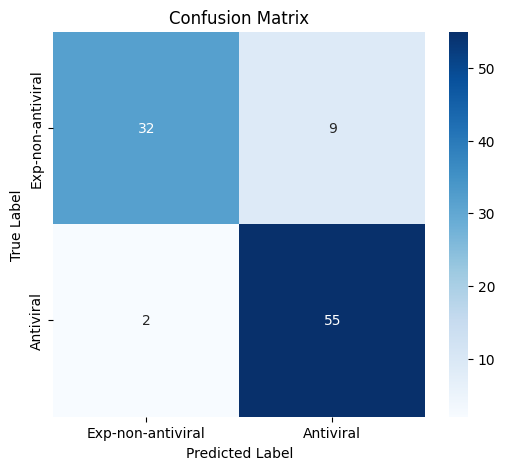


🔹 Classification Report:

                   precision    recall  f1-score   support

Exp-non-antiviral       0.94      0.78      0.85        41
        Antiviral       0.86      0.96      0.91        57

         accuracy                           0.89        98
        macro avg       0.90      0.87      0.88        98
     weighted avg       0.89      0.89      0.89        98



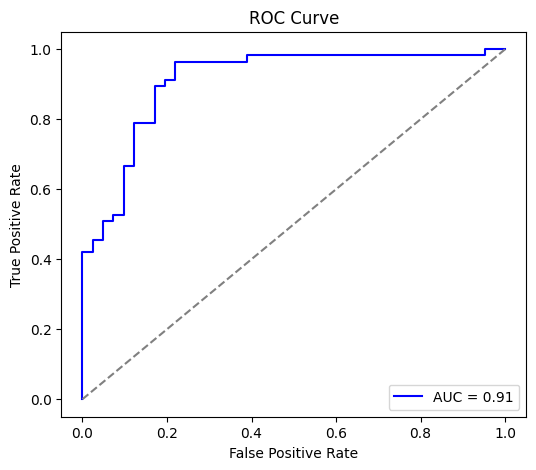

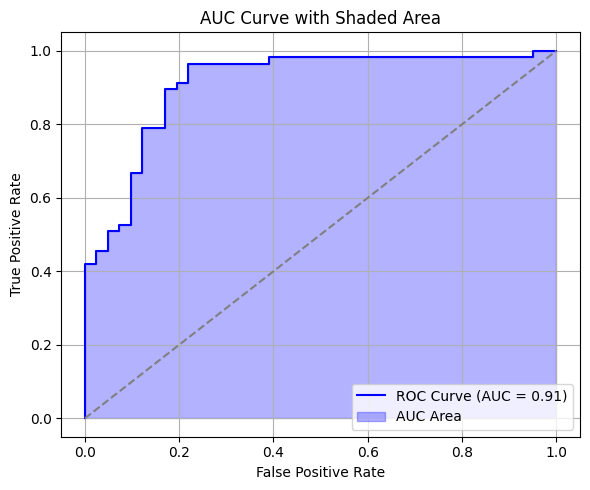

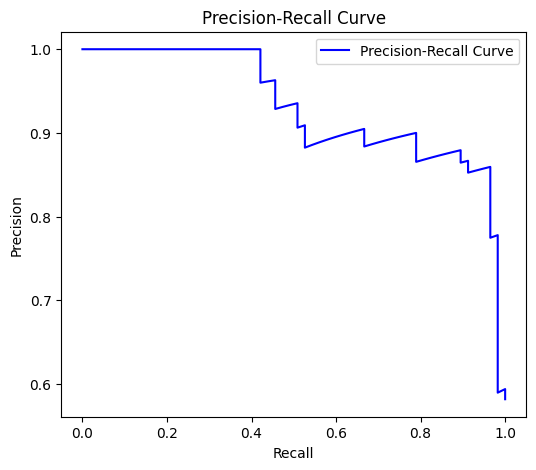

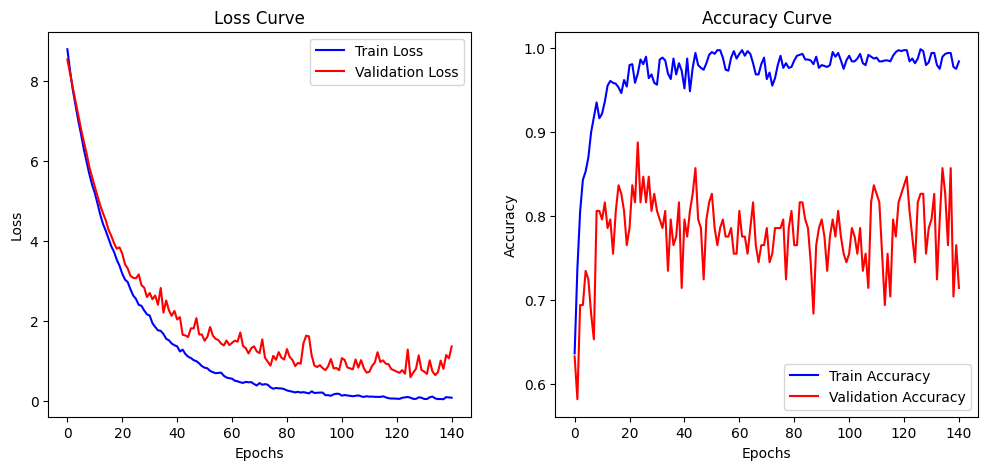

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 

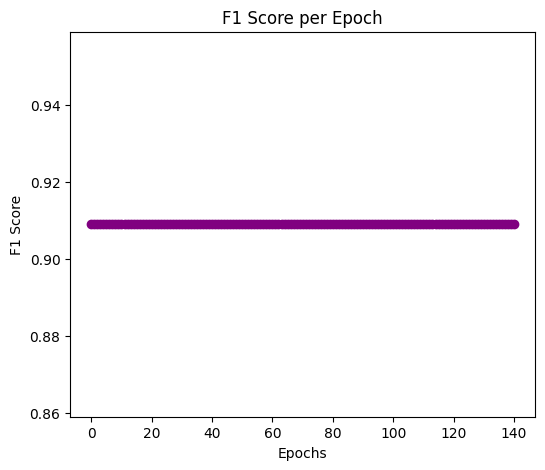

Cohen’s Kappa Score: 0.76
Matthews Correlation Coefficient (MCC): 0.77


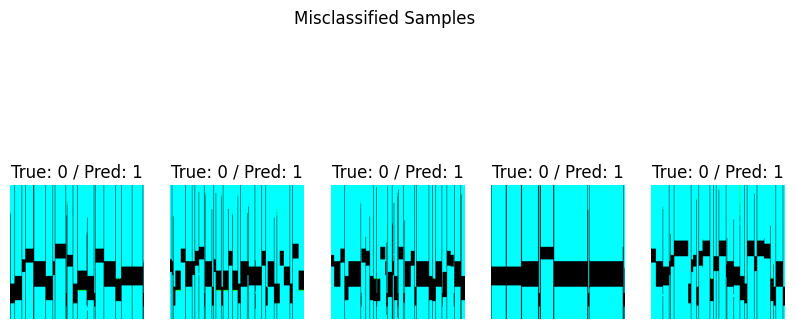


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8878
Precision 0.8594
   Recall 0.9649
 F1-score 0.9091
      AUC 0.9101
      MCC 0.7725
   G-mean 0.8678


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Exp-non-antiviral", "Antiviral"],
            yticklabels=["Exp-non-antiviral", "Antiviral"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2️⃣ Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Exp-non-antiviral", "Antiviral"]))

# 3️⃣ ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 🌟 Extra: AUC Curve with Shaded Area (for Presentation)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue', label='AUC Area')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve with Shaded Area')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# 5️⃣ Loss & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 6️⃣ F1 Score per Epoch
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6, 5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# 7️⃣ Cohen's Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# 8️⃣ Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# 9️⃣ Misclassified Samples
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10, 5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# 🔟 Performance Metrics Summary Table
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))
